In [5]:
import pandas as pd

In [ ]:
movies = pd.read_csv(r'C:\Users\alice\Desktop\Analyst Builder Practice & Project\Project\Python_Pandas_Project\imdb_movies.csv')

In [ ]:
movies.info()

In [ ]:
pd.set_option('display.max.rows',11000)
pd.set_option('display.max.columns',22)

In [ ]:
movies.head()

In [16]:
#movies[movies.duplicated() == True]
movies[movies.duplicated()]

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj


In [ ]:
movies.drop_duplicates(inplace = True)

In [17]:
movies.dropna(subset = 'genres', inplace = True)

In [20]:
#add profit column
movies['profit'] = movies['revenue'] - movies['budget'] 

In [23]:
#select useful columns
movies_genre = movies[['popularity','budget','revenue','original_title','runtime','genres','release_date','vote_count','vote_average','profit']]

In [ ]:
movies_genre.head()

In [51]:
#Turn list into series, dataframe
#Old way
from pandas import Series, DataFrame
split = movies_genre['genres'].str.split('|').apply(Series,1).stack()
split.index = split.index.droplevel(-1)
split

#New suggested way  
split = movies_genre['genres'].str.split('|', expand=True).stack()
split.index = split.index.droplevel(-1)
split

#Quickest way
split = movies_genre['genres'].str.split('|').explode()
split

C:\Users\alice\AppData\Local\Temp\ipykernel_24816\4136066635.py:4: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  split = movies_genre['genres'].str.split('|').apply(Series,1).stack()


0                 Action
0              Adventure
0        Science Fiction
0               Thriller
1                 Action
              ...       
10863            Mystery
10863             Comedy
10864             Action
10864             Comedy
10865             Horror
Name: genres, Length: 26955, dtype: object

In [ ]:
#rename Series
split.name = 'genres_split'
del movies_genre['genres']
movies_genre = movies_genre.join(split)

In [ ]:
#Gemini suggested
movie_genre = movies_genre.drop(columns='genres').join(movies_genre['genres'].str.split('|').explode().rename('genres_split'))

In [153]:
movies_genre.head()

,popularity,budget,revenue,original_title,runtime,release_date,vote_count,vote_average,profit,genres_split
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.50,1363528810,Action
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.50,1363528810,Adventure
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.50,1363528810,Science Fiction
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.50,1363528810,Thriller
1,28.42,150000000,378436354,Mad Max: Fury Road,120,5/13/15,6185,7.10,228436354,Action


### Research Questions (Q):

1.Which genres are the most common (number of movies made)?

In [71]:
#Way1
movie_common = movies_genre.groupby('genres_split')['original_title'].count().sort_values(ascending = False).reset_index()
movie_common.set_index('genres_split')

In [92]:
#Way2
genres_count = pd.DataFrame(movies_genre.groupby('genres_split').original_title.nunique()).sort_values('original_title', ascending = True)

<Axes: title={'center': 'Movies Per Genre in %'}, ylabel='original_title'>

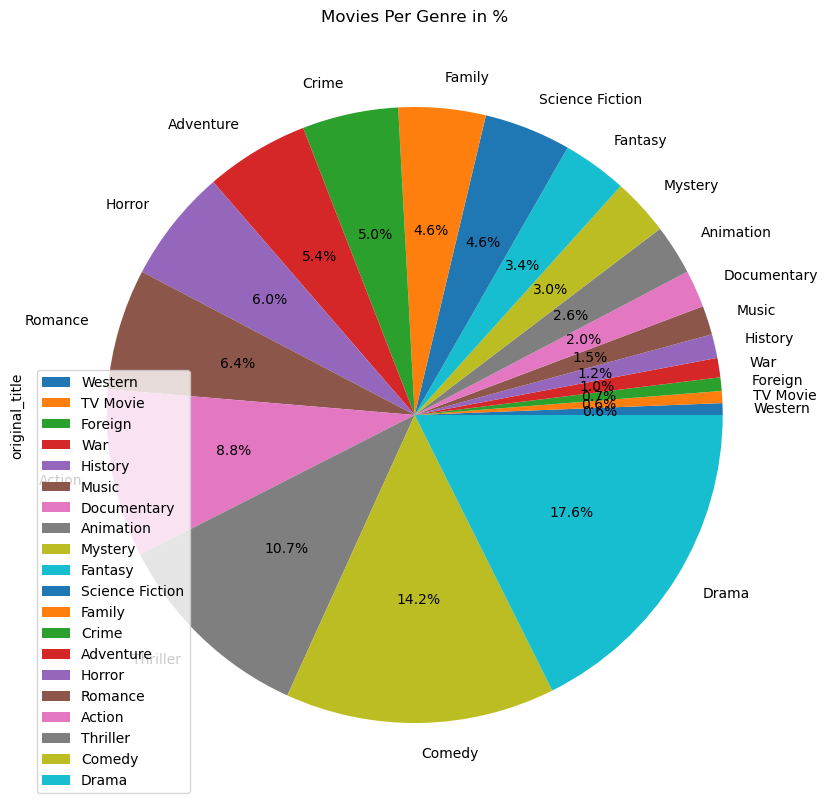

In [100]:
#Two ways
genres_count.plot.pie(y = 'original_title', title = 'Movies Per Genre in %', autopct = '%1.1f%%', figsize = (10,10))
genres_count['original_title'].plot.pie(title = 'Movies Per Genre in %', autopct = '%1.1f%%', figsize = (10,10))

<Axes: title={'center': 'Movies Per Genre'}, ylabel='genres_split'>

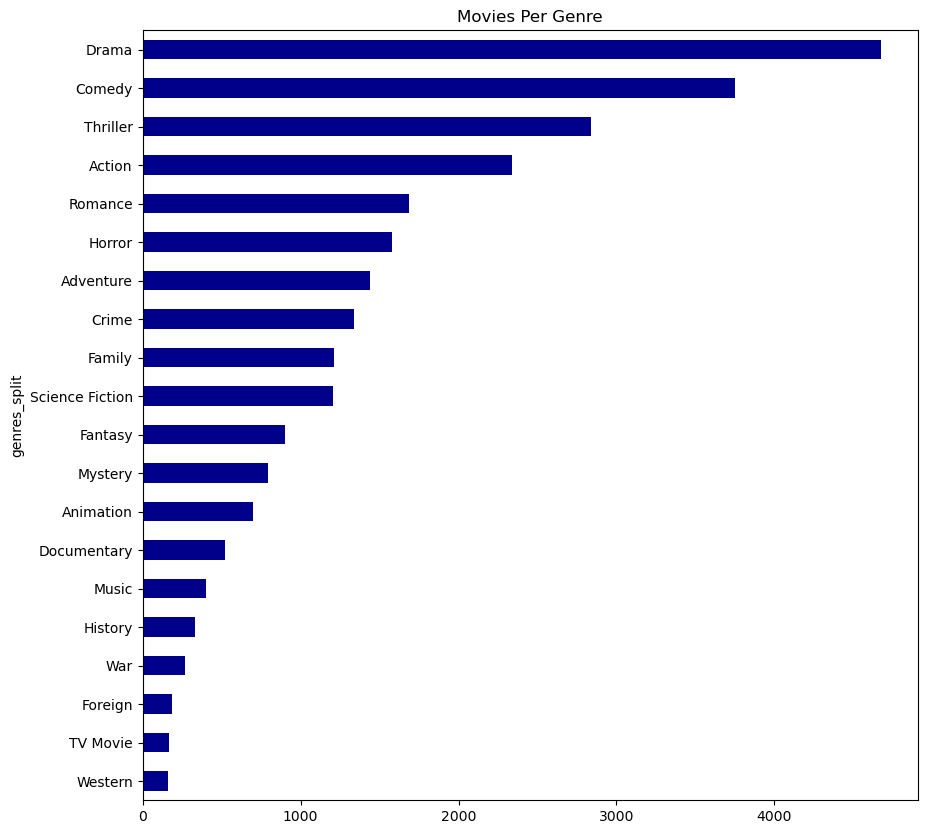

In [98]:
#horizontal bar
genres_count['original_title'].plot.barh(title = 'Movies Per Genre', color = 'darkblue', figsize = (10,10))

2.Which genres have high avg. budget and revenue?

In [107]:
genres_avg = movies_genre.groupby('genres_split').mean(numeric_only = True)
#turn scientific notation into float(can use astype() as well)
pd.options.display.float_format = '{:.2f}'.format
genres_avg

,popularity,budget,revenue,runtime,vote_count,vote_average,profit
genres_split,,,,,,,
Action,0.93,27727820.33,72794732.00,104.92,392.99,5.79,45066911.67
Adventure,1.15,37543694.53,113137861.07,106.17,513.13,5.94,75594166.54
Animation,0.85,23159781.61,75256062.22,68.18,303.00,6.40,52096280.62
Comedy,0.59,13297915.62,37526242.07,96.75,176.44,5.91,24228326.45
Crime,0.74,17663801.12,42368661.65,106.92,278.81,6.12,24704860.52
Documentary,0.18,577149.15,2041106.99,102.65,35.11,6.91,1463957.85
Drama,0.59,11880717.77,29232255.73,110.48,182.54,6.17,17351537.95
Family,0.79,23359337.42,72433176.37,89.60,272.32,6.00,49073838.95
Fantasy,0.99,32612585.35,96313657.08,100.74,420.74,5.86,63701071.73


In [117]:
genres_avg.sort_values('budget', ascending = True, inplace = True)

<Axes: title={'center': 'Budget and Revenue by Genre'}, ylabel='genres_split'>

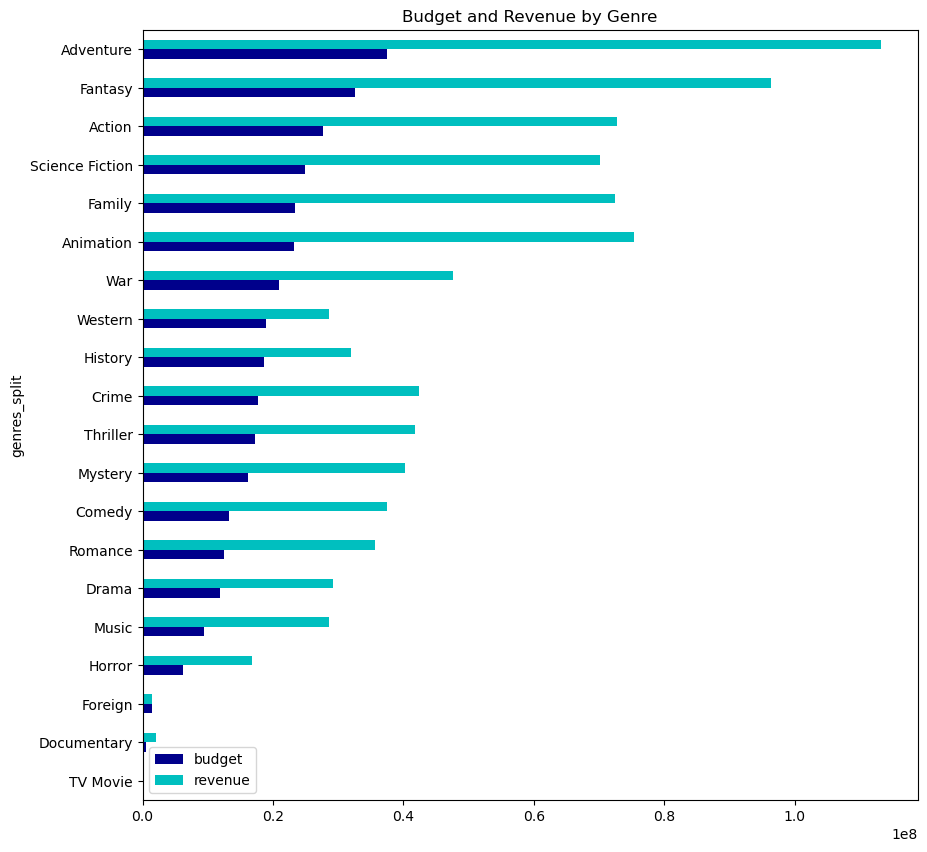

In [122]:
#Way1
genres_avg.plot.barh(y = ['budget','revenue'], title = 'Budget and Revenue by Genre', color = ('darkblue', 'c'), figsize = (10,10))
#Way2
genres_avg[['budget','revenue']].plot.barh(title = 'Budget and Revenue by Genre', color = ('darkblue', 'c'), figsize = (10,10))

2.Which genres have high avg. profit?

<Axes: title={'center': 'Profit by Genre'}, ylabel='genres_split'>

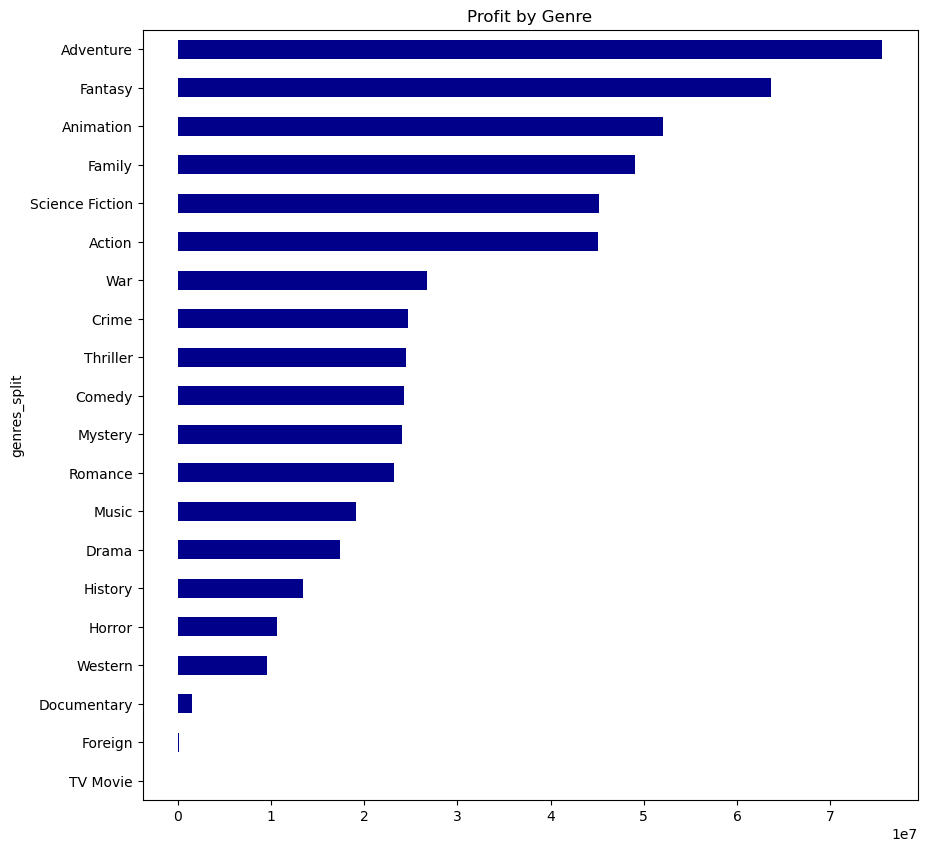

In [123]:
genres_avg.sort_values('profit', ascending = True, inplace = True)
genres_avg['profit'].plot.barh(title = 'Profit by Genre', color = 'darkblue', figsize = (10,10))

3.Which genres have high avg. popularity?

<Axes: title={'center': 'popularity by Genre'}, ylabel='genres_split'>

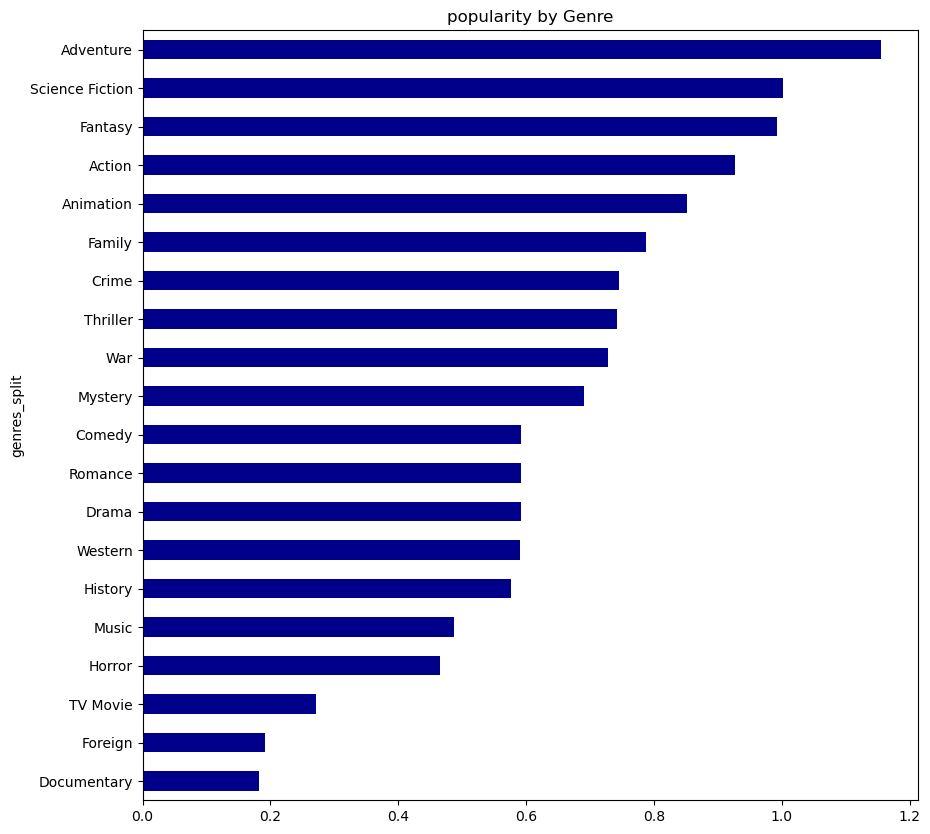

In [124]:
genres_avg.sort_values('popularity', ascending = True, inplace = True)
genres_avg['popularity'].plot.barh(title = 'popularity by Genre', color = 'darkblue', figsize = (10,10))

4.Which genres have highest number of movies with an voting avg. >= 8?

In [125]:
movies_genre.head()

,popularity,budget,revenue,original_title,runtime,release_date,vote_count,vote_average,profit,genres_split
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.50,1363528810,Action
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.50,1363528810,Adventure
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.50,1363528810,Science Fiction
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.50,1363528810,Thriller
1,28.42,150000000,378436354,Mad Max: Fury Road,120,5/13/15,6185,7.10,228436354,Action


In [132]:
vote_fifty = movies_genre[(movies_genre['vote_average'] >= 8) & (movies_genre['vote_count'] >= 50)]
vote_zero = movies_genre[movies_genre['vote_average'] >= 8]

In [145]:
genres_vote1 = pd.DataFrame(vote_fifty.groupby('genres_split').original_title.nunique()).sort_values('original_title')	

<Axes: title={'center': 'Number of movies with an voting avg. >= 8 and vote_count > 50 by Genre'}, ylabel='genres_split'>

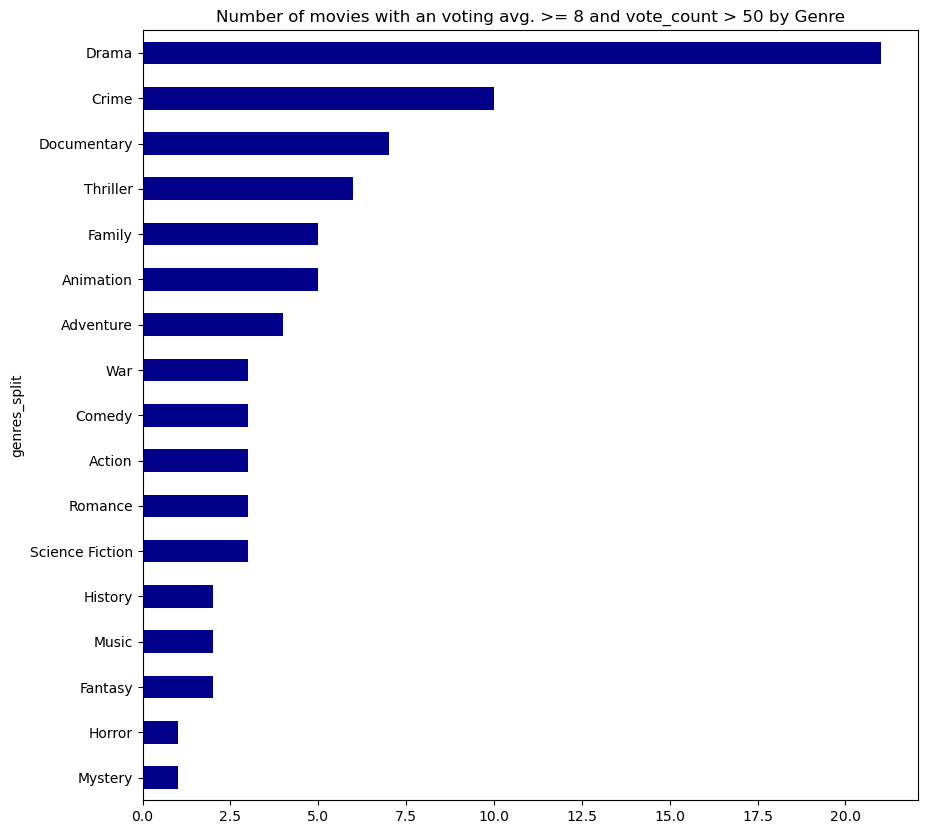

In [150]:
genres_vote1['original_title'].plot.barh(title = 'Number of movies with an voting avg. >= 8 and vote_count > 50 by Genre', color = 'darkblue', figsize = (10,10))

In [146]:
genres_vote2 = pd.DataFrame(vote_zero.groupby('genres_split').original_title.nunique()).sort_values('original_title')	

<Axes: title={'center': 'Number of movies with an voting avg. >= 8'}, ylabel='genres_split'>

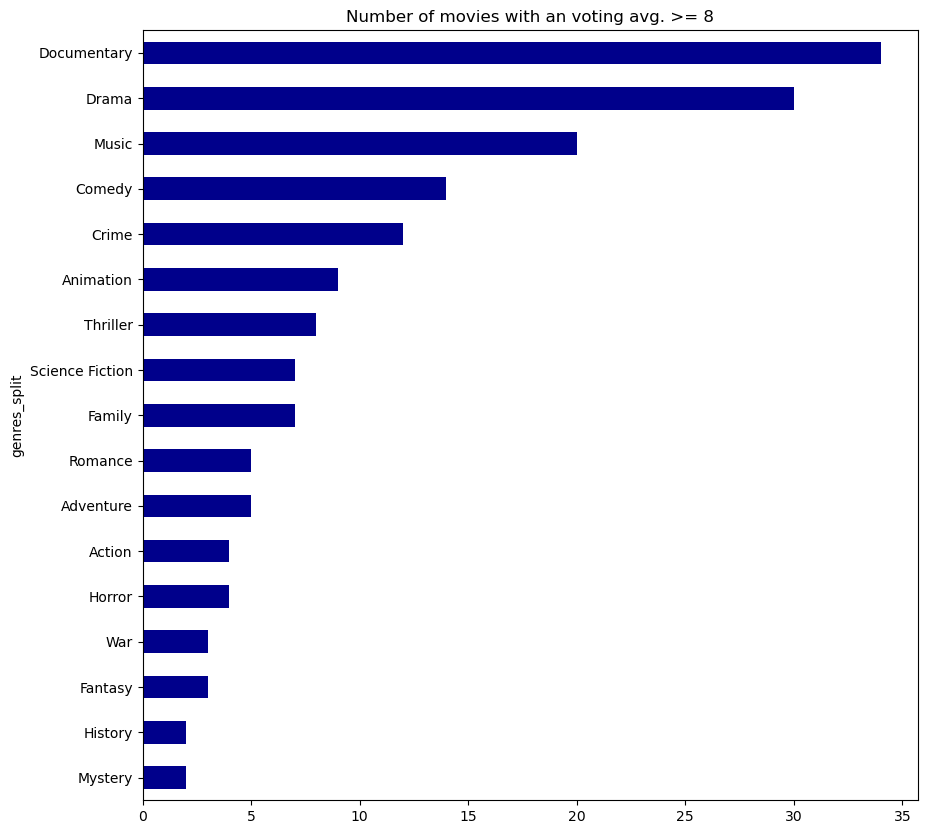

In [151]:
genres_vote2['original_title'].plot.barh(title = 'Number of movies with an voting avg. >= 8', color = 'darkblue', figsize = (10,10))

### Research Hypothesis (H):

In [155]:
import pandas as pd
movies = pd.read_csv(r'C:\Users\alice\Desktop\Analyst Builder Practice & Project\Project\Python_Pandas_Project\imdb_movies.csv')
pd.set_option('display.max.rows',11000)
pd.set_option('display.max.columns',22)
movies.drop_duplicates(inplace = True)
movies['profit'] = movies['revenue'] - movies['budget'] 
movies_genre = movies[['popularity','budget','revenue','original_title','runtime','genres','release_date','vote_count','vote_average','profit',]]

In [156]:
movies_genre.head()

,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,profit
0,32.99,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.50,1363528810
1,28.42,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.10,228436354
2,13.11,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.30,185238201
3,11.17,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.50,1868178225
4,9.34,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.30,1316249360


1.The best movies according to vote avg. return high profit and revenue.

In [157]:
#filter down the vote_count
movies_counted = movies_genre[movies_genre['vote_count'] >= 50]
movies_counted.corr(numeric_only = True, method = 'spearman')

,popularity,budget,revenue,runtime,vote_count,vote_average,profit
popularity,1.00,0.49,0.59,0.23,0.77,0.19,0.50
budget,0.49,1.00,0.71,0.36,0.55,-0.04,0.33
revenue,0.59,0.71,1.00,0.34,0.68,0.11,0.84
runtime,0.23,0.36,0.34,1.00,0.26,0.29,0.21
vote_count,0.77,0.55,0.68,0.26,1.00,0.28,0.58
vote_average,0.19,-0.04,0.11,0.29,0.28,1.00,0.20
profit,0.50,0.33,0.84,0.21,0.58,0.20,1.00


<Axes: xlabel='vote_average', ylabel='profit'>

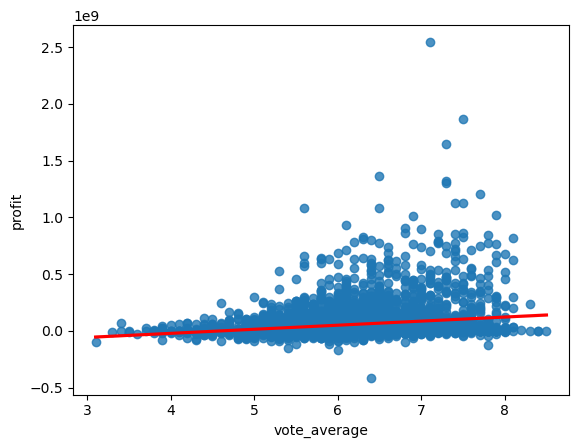

In [164]:
import seaborn as sns
sns.regplot(data = movies_counted, x = 'vote_average', y = 'profit', line_kws = {'color':'red'})

<Axes: xlabel='vote_average', ylabel='revenue'>

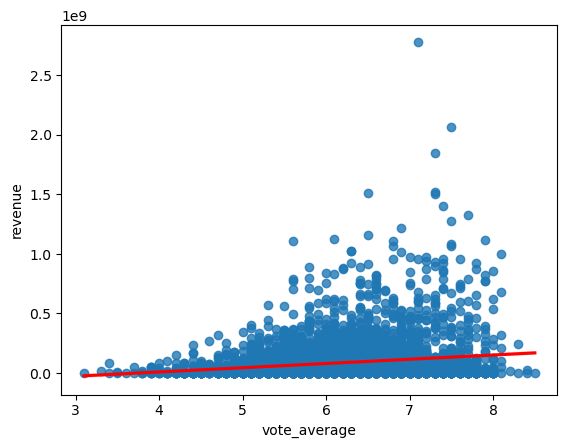

In [165]:
import seaborn as sns
sns.regplot(data = movies_counted, x = 'vote_average', y = 'revenue', line_kws = {'color':'red'})

2.The best movies according to popularity return high profit and revenue.

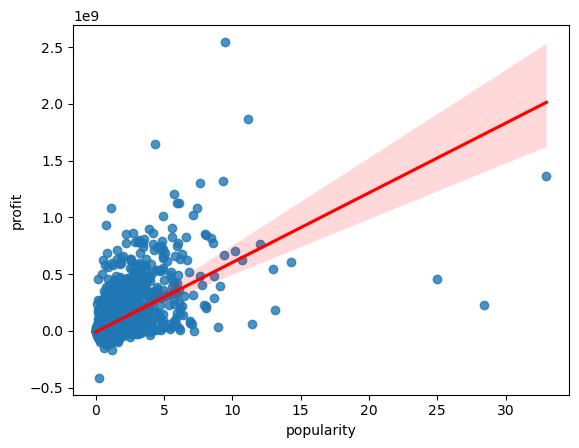

<Figure size 2000x1000 with 0 Axes>

In [175]:
import seaborn as sns
sns.regplot(data = movies_counted, x = 'popularity', y = 'profit', line_kws = {'color':'red'})
plt.figure(figsize = (20,10))
plt.show()

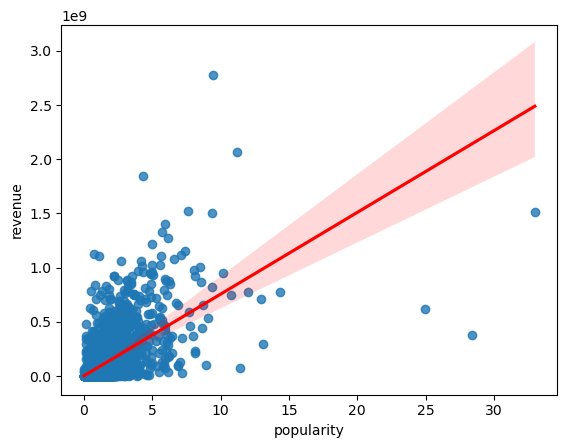

<Figure size 2000x1000 with 0 Axes>

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.regplot(data = movies_counted, x = 'popularity', y = 'revenue', line_kws = {'color':'red'})
plt.figure(figsize = (20,10))
plt.show()

3.Highly budgeted movies return high revenue and profit.

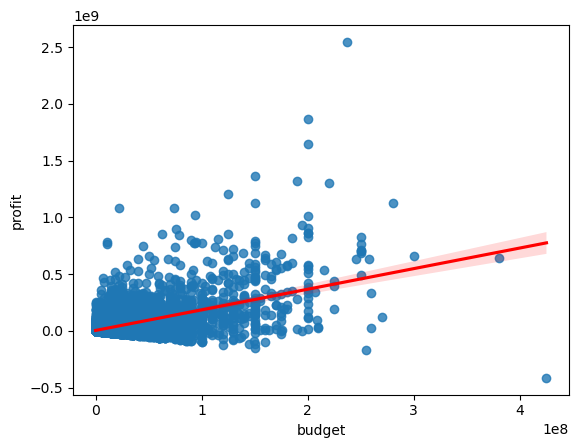

<Figure size 2000x1000 with 0 Axes>

In [185]:
sns.regplot(data = movies_counted, x = 'budget', y = 'profit', line_kws = {'color':'red'})
plt.figure(figsize = (20,10))
plt.show()

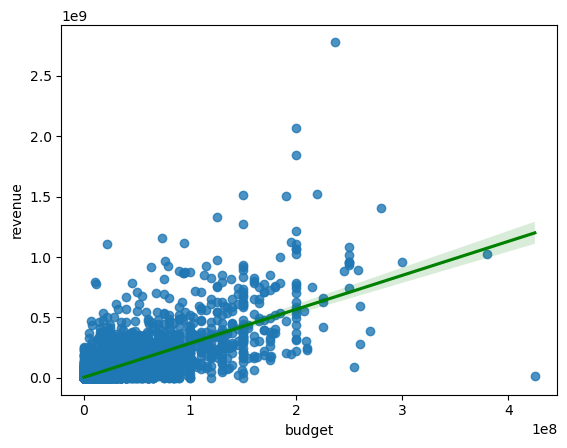

<Figure size 2000x1000 with 0 Axes>

In [186]:
sns.regplot(data = movies_counted, x = 'budget', y = 'revenue', line_kws = {'color':'green'})
plt.figure(figsize = (20,10))
plt.show()

4.Highly budgeted movies have a high popularity.

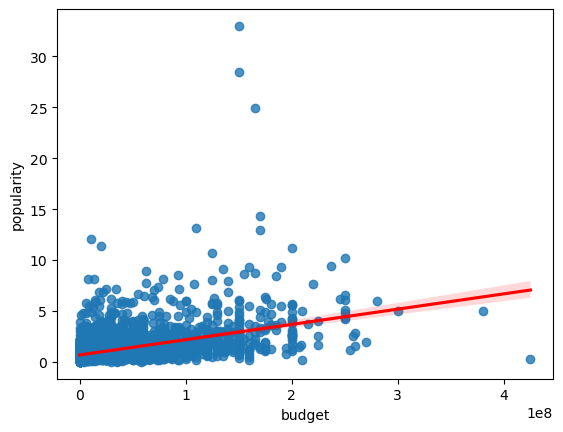

<Figure size 2000x1000 with 0 Axes>

In [187]:
sns.regplot(data = movies_counted, x = 'budget', y = 'popularity', line_kws = {'color':'red'})
plt.figure(figsize = (20,10))
plt.show()

In [ ]:
5.Take a look at Profit per Genre Per Year

In [195]:
import pandas as pd
movies = pd.read_csv(r'C:\Users\alice\Desktop\Analyst Builder Practice & Project\Project\Python_Pandas_Project\imdb_movies.csv')
pd.set_option('display.max.rows',11000)
pd.set_option('display.max.columns',22)
movies.drop_duplicates(inplace = True)
movies.dropna(subset = 'genres', inplace = True)
movies['profit'] = movies['revenue'] - movies['budget'] 
#Select useful columns
movies_genre = movies[['popularity','budget','revenue','original_title','runtime','genres','release_year','vote_count','vote_average','profit']]
#Split column and explode
split = movies_genre['genres'].str.split('|').explode()
#rename Series and join dataframe
split.name = 'genres_split'
del movies_genre['genres']
movies_genre = movies_genre.join(split)
movies_genre.head()

,popularity,budget,revenue,original_title,runtime,release_year,vote_count,vote_average,profit,genres_split
0,32.99,150000000,1513528810,Jurassic World,124,2015,5562,6.50,1363528810,Action
0,32.99,150000000,1513528810,Jurassic World,124,2015,5562,6.50,1363528810,Adventure
0,32.99,150000000,1513528810,Jurassic World,124,2015,5562,6.50,1363528810,Science Fiction
0,32.99,150000000,1513528810,Jurassic World,124,2015,5562,6.50,1363528810,Thriller
1,28.42,150000000,378436354,Mad Max: Fury Road,120,2015,6185,7.10,228436354,Action


In [198]:
time_genre = pd.DataFrame(movies_genre.groupby(['release_year','genres_split'])['profit'].mean())

In [201]:
time_genre.head()

profit
release_year genres_split           
1960         Action       6363125.00
             Adventure     431000.00
             Comedy       5258750.00
             Crime              0.00
             Drama        8245619.38

In [205]:
#Way1
final_genre = time_genre.unstack(level = 0)
#Way2
final_genre = pd.pivot_table(data = time_genre, values = 'profit', index = 'genres_split', columns = 'release_year')

In [213]:
final_genre.head()

release_year,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
genres_split,,,,,,,,,,,,,,,,,,,,,,,
Action,6363125.00,2457142.86,10437500.00,14999691.25,24280000.00,16104504.78,324785.71,21732786.43,8868478.83,5861449.30,7735913.45,...,32379154.19,38048623.21,45977444.05,47642764.40,57555510.74,34571030.36,51968078.25,71910257.42,47431725.63,69943650.02,90399046.75
Adventure,431000.00,39130002.33,21214285.71,9428395.00,24123400.00,25124276.33,791563.64,49281873.86,15122159.40,16651809.40,11406377.67,...,70756754.32,64895200.09,83916731.08,55016526.81,113364919.74,98125646.68,113343224.56,162549574.30,100638113.40,120373306.99,144787868.97
Animation,NaN,211880014.00,NaN,0.00,0.00,0.00,-105000.00,100921706.00,0.00,0.00,25837628.50,...,40307312.15,39047734.97,67147670.53,51907242.58,48862898.25,58455658.64,63420098.93,69231546.88,93718795.26,64313463.25,83691174.38
Comedy,5258750.00,22198001.40,1599974.80,765591.92,7080111.38,3264285.71,-149550.00,10135087.47,-1277777.78,-125000.00,11901488.58,...,22147617.44,24944308.17,30674848.55,21483012.43,24741982.81,23154807.88,27241358.72,25631999.14,25068455.09,26648786.86,33703819.07
Crime,0.00,18828411.00,3709948.67,369526.75,1723307.30,-22500.00,-275560.00,12899678.71,6762174.60,31482963.00,-2125000.00,...,15680793.69,21551432.96,16700048.40,31258696.85,11016642.31,13490412.32,25395271.62,29522925.56,23248589.51,5903014.23,61286524.37


Text(0.5, 1.0, 'Genre by Profit per Year')

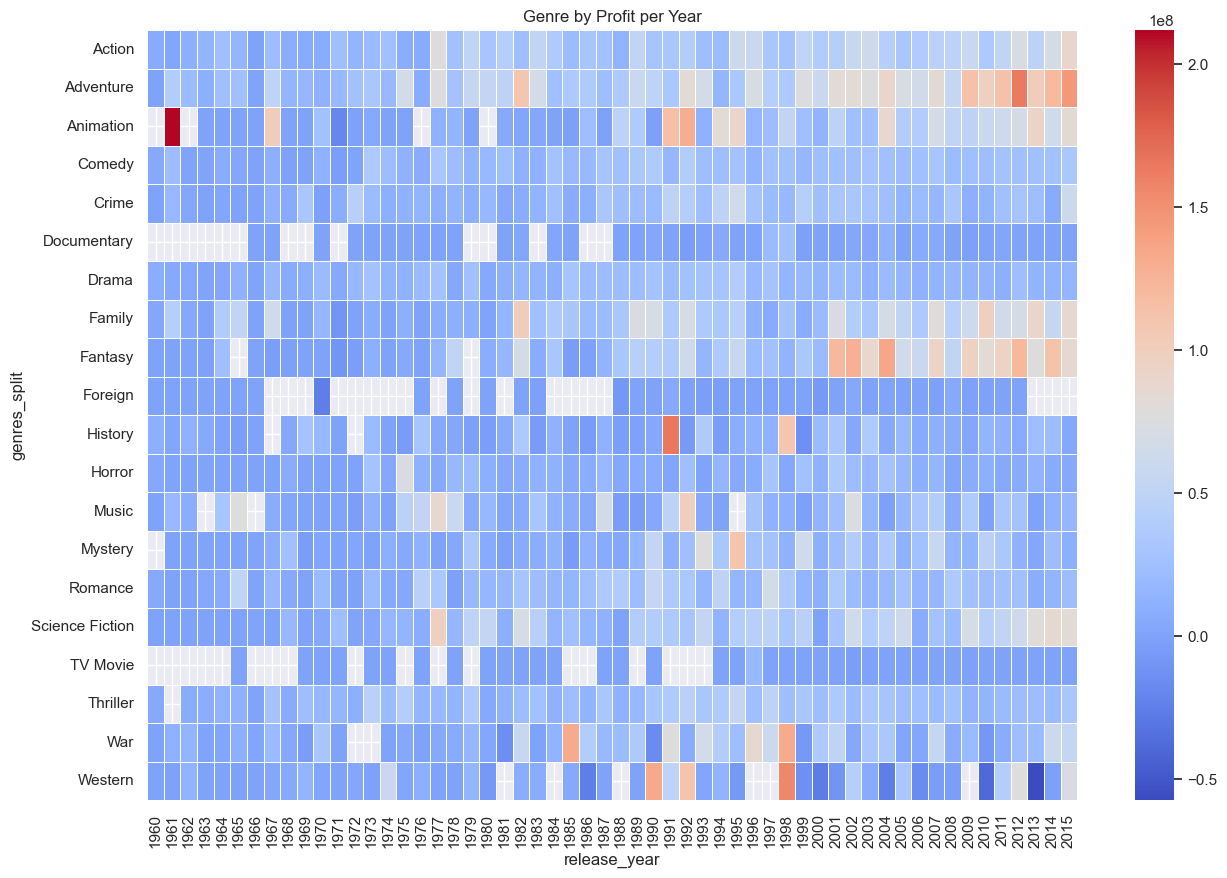

In [210]:
import seaborn as sns
sns.set(rc = {'figure.figsize':(15,10)})
sns.heatmap(data = final_genre, cmap = 'coolwarm', linewidths = 0.5)
plt.title('Genre by Profit per Year')

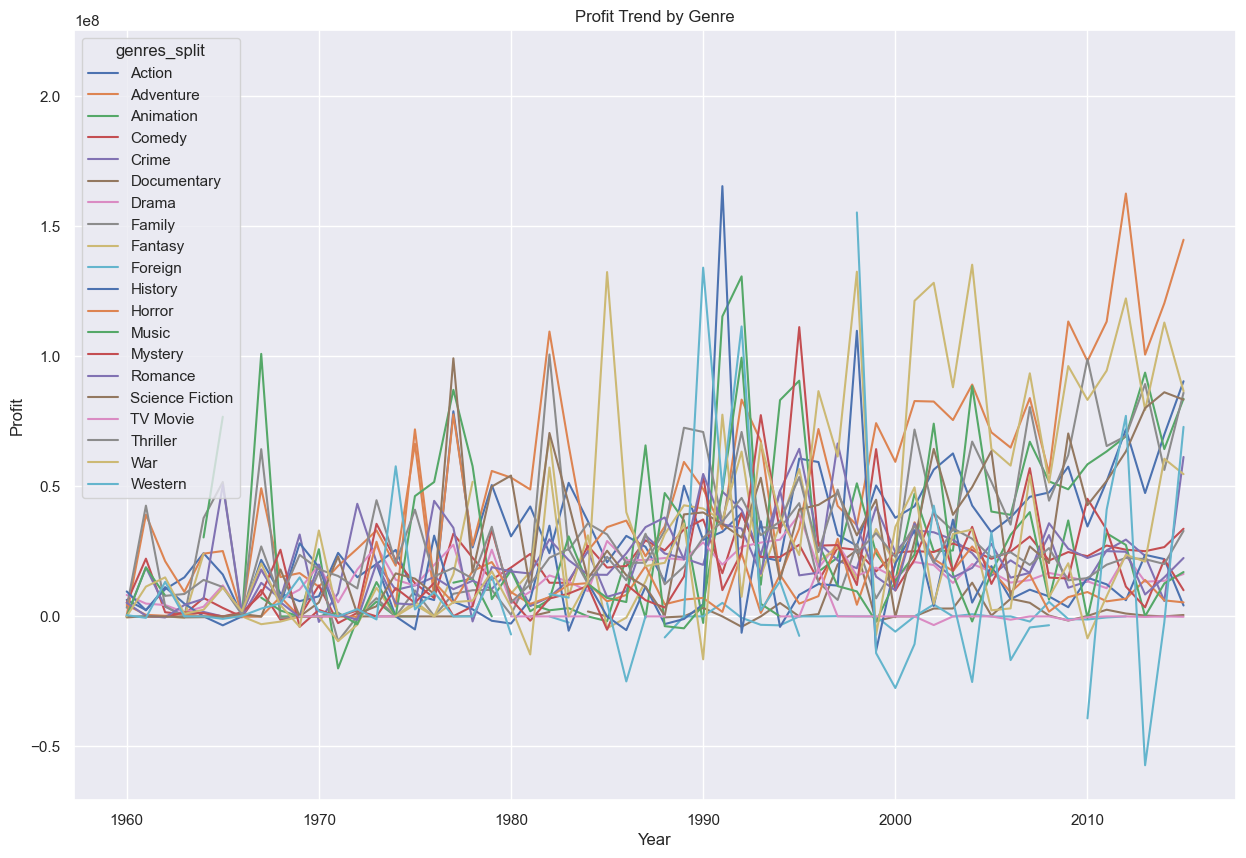

In [219]:
final_genre.T.plot(kind='line', figsize=(15, 10))
plt.title('Profit Trend by Genre')
plt.ylabel('Profit')
plt.xlabel('Year')
plt.show()

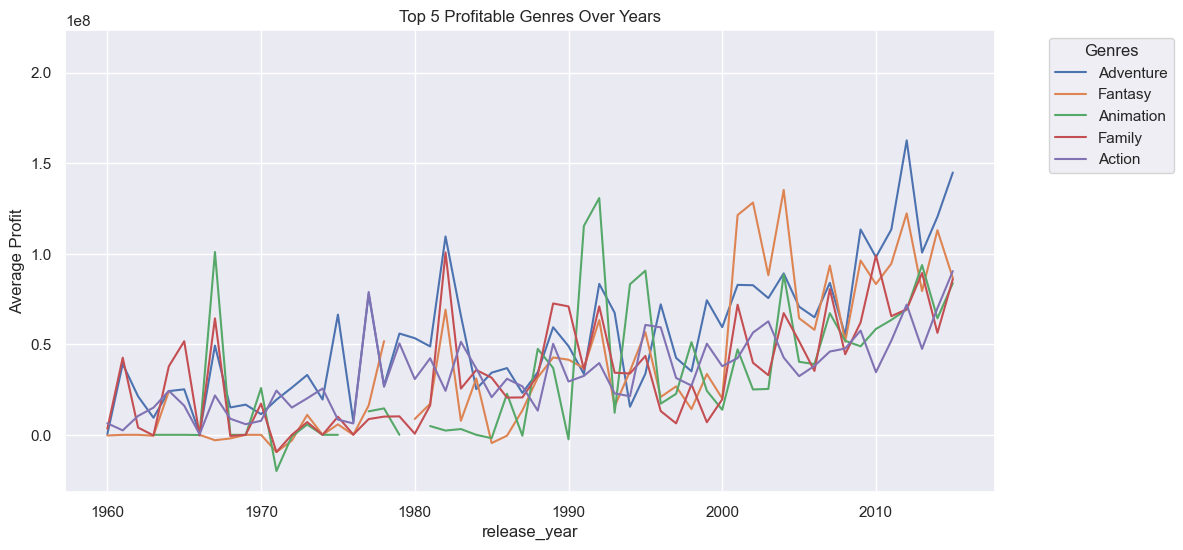

In [231]:
top_5_names = final_genre.mean(axis=1).nlargest(5).index
final_genre.loc[top_5_names].T.plot(kind='line', figsize=(12, 6))
plt.title('Top 5 Profitable Genres Over Years')
plt.ylabel('Average Profit')
plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

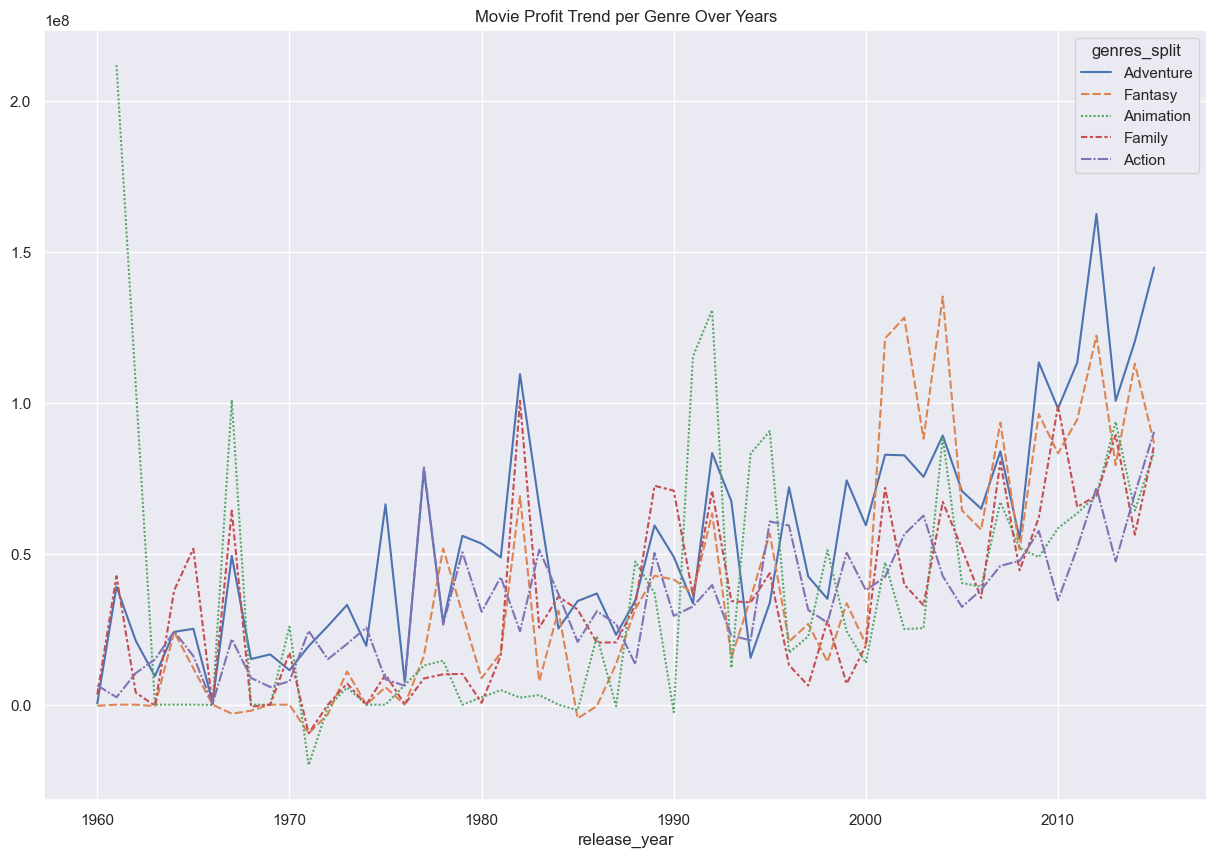

In [245]:
import matplotlib.pyplot as plt
sns.set(rc={'figure.figsize':(15, 10)})

top_5_names = final_genre.mean(axis=1).nlargest(5).index
final_genre2 = final_genre.loc[top_5_names]
final_genre2 = final_genre2.T.reset_index().set_index('release_year')

sns.lineplot(data = final_genre2)

plt.title('Movie Profit Trend per Genre Over Years')
plt.show()
